Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


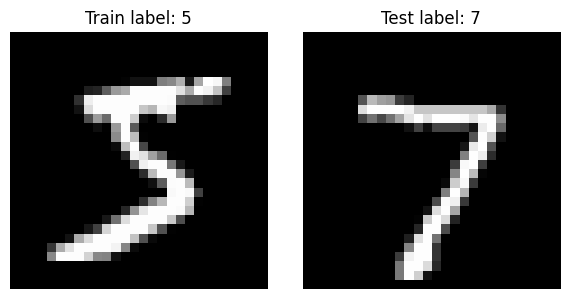

In [1]:
import gzip
import ssl
import struct
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = Path("data/mnist")
DATA_DIR.mkdir(parents=True, exist_ok=True)
BASE_URL = "https://storage.googleapis.com/cvdf-datasets/mnist/"
FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}


def download_file(url: str, path: Path) -> None:
    ctx = ssl._create_unverified_context()
    with urllib.request.urlopen(url, context=ctx) as resp, open(path, "wb") as out:
        out.write(resp.read())


def download_mnist():
    for name, fname in FILES.items():
        path = DATA_DIR / fname
        if not path.exists():
            url = BASE_URL + fname
            print(f"Downloading {fname}...")
            download_file(url, path)


def read_idx(path: Path) -> np.ndarray:
    with gzip.open(path, "rb") as f:
        magic, = struct.unpack(">I", f.read(4))
        if magic not in (2051, 2049):
            raise ValueError(f"Unexpected magic number: {magic}")
        num_dims = magic % 256
        dims = struct.unpack(">" + "I" * num_dims, f.read(4 * num_dims))
        data = np.frombuffer(f.read(), dtype=np.uint8)
        return data.reshape(dims)


download_mnist()

train_images = read_idx(DATA_DIR / FILES["train_images"]).astype(np.float32)
train_labels = read_idx(DATA_DIR / FILES["train_labels"]).astype(np.int64)
test_images = read_idx(DATA_DIR / FILES["test_images"]).astype(np.float32)
test_labels = read_idx(DATA_DIR / FILES["test_labels"]).astype(np.int64)

print("Train:", train_images.shape, train_labels.shape)
print("Test:", test_images.shape, test_labels.shape)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(train_images[0], cmap="gray")
axes[0].set_title(f"Train label: {train_labels[0]}")
axes[0].axis("off")
axes[1].imshow(test_images[0], cmap="gray")
axes[1].set_title(f"Test label: {test_labels[0]}")
axes[1].axis("off")
plt.tight_layout()
plt.show()


In [2]:
def one_hot(labels: np.ndarray, num_classes: int = 10) -> np.ndarray:
    out = np.zeros((labels.size, num_classes), dtype=np.float32)
    out[np.arange(labels.size), labels] = 1.0
    return out

X_train = train_images.reshape(train_images.shape[0], -1) / 255.0
X_test = test_images.reshape(test_images.shape[0], -1) / 255.0
y_train = one_hot(train_labels)
y_test = one_hot(test_labels)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


X_train: (60000, 784) y_train: (60000, 10)
X_test: (10000, 784) y_test: (10000, 10)


In [3]:
rng = np.random.default_rng(42)

input_dim = 28 * 28
hidden_dim = 128
num_classes = 10

W1 = rng.normal(0, np.sqrt(2 / input_dim), size=(input_dim, hidden_dim)).astype(np.float32)
b1 = np.zeros(hidden_dim, dtype=np.float32)
W2 = rng.normal(0, np.sqrt(2 / hidden_dim), size=(hidden_dim, num_classes)).astype(np.float32)
b2 = np.zeros(num_classes, dtype=np.float32)


def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(0, x)


def softmax(logits: np.ndarray) -> np.ndarray:
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)


def forward(x: np.ndarray):
    z1 = x @ W1 + b1
    a1 = relu(z1)
    logits = a1 @ W2 + b2
    probs = softmax(logits)
    return z1, a1, logits, probs


def cross_entropy(probs: np.ndarray, targets: np.ndarray) -> float:
    eps = 1e-9
    return -np.mean(np.sum(targets * np.log(probs + eps), axis=1))


def accuracy(probs: np.ndarray, labels: np.ndarray) -> float:
    preds = np.argmax(probs, axis=1)
    return np.mean(preds == labels)


In [4]:
epochs = 20
batch_size = 128
learning_rate = 0.1

num_samples = X_train.shape[0]
loss_history = []

for epoch in range(1, epochs + 1):
    indices = rng.permutation(num_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]

    epoch_loss = 0.0
    for start in range(0, num_samples, batch_size):
        end = start + batch_size
        x_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        z1, a1, logits, probs = forward(x_batch)
        loss = cross_entropy(probs, y_batch)
        epoch_loss += loss * x_batch.shape[0]

        grad_logits = (probs - y_batch) / x_batch.shape[0]
        grad_W2 = a1.T @ grad_logits
        grad_b2 = grad_logits.sum(axis=0)

        grad_a1 = grad_logits @ W2.T
        grad_z1 = grad_a1 * (z1 > 0)
        grad_W1 = x_batch.T @ grad_z1
        grad_b1 = grad_z1.sum(axis=0)

        W2 -= learning_rate * grad_W2
        b2 -= learning_rate * grad_b2
        W1 -= learning_rate * grad_W1
        b1 -= learning_rate * grad_b1

    epoch_loss /= num_samples
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch}/{epochs} - loss: {epoch_loss:.4f}")


Epoch 1/20 - loss: 0.4570
Epoch 2/20 - loss: 0.2569
Epoch 3/20 - loss: 0.2074
Epoch 4/20 - loss: 0.1752
Epoch 5/20 - loss: 0.1522
Epoch 6/20 - loss: 0.1342
Epoch 7/20 - loss: 0.1205
Epoch 8/20 - loss: 0.1092
Epoch 9/20 - loss: 0.0997
Epoch 10/20 - loss: 0.0922
Epoch 11/20 - loss: 0.0854
Epoch 12/20 - loss: 0.0797
Epoch 13/20 - loss: 0.0745
Epoch 14/20 - loss: 0.0699
Epoch 15/20 - loss: 0.0652
Epoch 16/20 - loss: 0.0620
Epoch 17/20 - loss: 0.0586
Epoch 18/20 - loss: 0.0555
Epoch 19/20 - loss: 0.0527
Epoch 20/20 - loss: 0.0499


Final training accuracy: 98.79%
Final testing accuracy: 97.69%


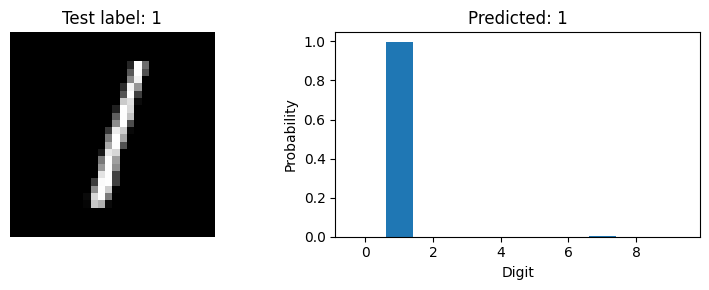

In [7]:
_, _, _, train_probs = forward(X_train)
_, _, _, test_probs = forward(X_test)

train_acc = accuracy(train_probs, train_labels)
test_acc = accuracy(test_probs, test_labels)

print(f"Final training accuracy: {train_acc * 100:.2f}%")
print(f"Final testing accuracy: {test_acc * 100:.2f}%")

sample_idx = 2
sample_image = test_images[sample_idx]
sample_prob = test_probs[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(sample_image, cmap="gray")
axes[0].set_title(f"Test label: {test_labels[sample_idx]}")
axes[0].axis("off")

axes[1].bar(np.arange(10), sample_prob)
axes[1].set_xlabel("Digit")
axes[1].set_ylabel("Probability")
axes[1].set_title(f"Predicted: {np.argmax(sample_prob)}")
plt.tight_layout()
plt.show()
